Strategy:

1.   Load EfficientNet-B2 with frozen backbone → train only the classifier head (few epochs)
2.   Unfreeze the whole network → fine-tune end-to-end with a lower LR
3. Evaluate on the test set and compare against the SimpleCNN baseline

In [ ]:
import zipfile
import os
from glob import glob
import random
from pathlib import Path
import time
from typing import Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Paths / device

In [ ]:
# Define device-agnostic code for flexibility
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
%cd /content/drive/MyDrive/UPF_Deep_Learning_2026/final_project

metadata_csv = "data/HAM10000_metadata.csv"

results_path = "results"
os.makedirs(results_path, exist_ok=True)

# Load images and preprocessing

Copy data to local disk

In [ ]:
import os
import shutil
from pathlib import Path


SRC_DIR = Path("/content/drive/MyDrive/UPF_Deep_Learning_2026/final_project/images/imatges_ham10000")
DST_DIR = Path("/content/images1")

print("Saving images to local disk...")

if not DST_DIR.exists():
    shutil.copytree(SRC_DIR, DST_DIR)
else:
    print("Images already copied. Skipping copy.")

print(f"Copied / available images: {len(list(DST_DIR.iterdir()))}")

Saving images to local disk...
Images already copied. Skipping copy.
Copied / available images: 104


In [ ]:
df = pd.read_csv(metadata_csv)

destination_folder = Path("images/imatges_ham10000")

if not destination_folder.exists():
    zip_files = [
        Path('images/HAM10000_images_part_1.zip'),
        Path('images/HAM10000_images_part_2.zip')
    ]
    os.makedirs(destination_folder, exist_ok=True)
    print("Extracting dataset...")
    for f in zip_files:
        with zipfile.ZipFile(f, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)
else:
    print("Dataset already extracted")

image_paths = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(destination_folder, '*.jpg'))
}

df['path'] = df['image_id'].map(image_paths)

before = len(df)
df = df.dropna(subset=['path']).reset_index(drop=True)
print(f"Removed {before - len(df)} missing paths · Remaining: {len(df)}")

corrupt_ids = ['ISIC_0024332', 'ISIC_0025870']
df = df[~df['image_id'].isin(corrupt_ids)].reset_index(drop=True)


display(df.head())

Dataset already extracted
Removed 2 missing paths · Remaining: 10013


,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,images/imatges_ham10000/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,images/imatges_ham10000/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,images/imatges_ham10000/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,images/imatges_ham10000/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,images/imatges_ham10000/ISIC_0031633.jpg


In [ ]:

SEED = 42

gss_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss_1.split(df, groups=df["lesion_id"])
)

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

gss_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    gss_2.split(temp_df, groups=temp_df["lesion_id"])
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()


print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 8022
Val:   993
Test:  998


# Data augmentation and normalization

In [ ]:
IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class_to_idx = {
    'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6
}

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'path']
        label_str = self.dataframe.loc[idx, 'dx']

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label_idx = class_to_idx[label_str]
        return image, torch.tensor(label_idx, dtype=torch.long)

# Transforms

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Imbalanced management

In [ ]:
train_counts = (
    train_df["dx"]
    .map(class_to_idx)
    .value_counts()
    .reindex(range(len(class_to_idx)),fill_value=0)# If a class has 0 samples in train, value_counts() drops it entire misaligning weights with class indices. reindex ensures all 7 classes appear.
    .sort_index()
    .values
)


N = train_counts.sum()
K = len(class_to_idx)

class_weights_np = N / (K* np.clip(train_counts,1,None))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

print("Class weights:", class_weights)

Class weights: tensor([ 0.2131,  1.3157,  1.3097,  2.6467,  4.3245, 10.4182, 12.5934])


In [ ]:
train_ds = HAM10000Dataset(train_df, transform=train_transforms)
val_ds   = HAM10000Dataset(val_df,   transform=val_transforms)
test_ds  = HAM10000Dataset(test_df,  transform=test_transforms)

train_sample_weights = []


for dx in train_df["dx"].values:
    idx    = class_to_idx[dx]
    weight = class_weights[idx].item()
    train_sample_weights.append(weight)

train_sampler = WeightedRandomSampler(
    weights=train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True
)

BATCH_SIZE = 32
train_loader_rs = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=2, pin_memory=True) #with weighted random sampler
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 251
Val batches:   32
Test batches:  32


# EfficientNet-B2

In [ ]:
def build_efficientnet_b2(num_classes: int = 7, freeze_backbone: bool = True) -> nn.Module:
    """
    Load EfficientNet-B2 pretrained on ImageNet and replace its classifier head.

    Args:
        num_classes:      Number of output classes.
        freeze_backbone:  If True, freeze all layers except the new head.

    Returns:
        nn.Module ready to move to device.
    """
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # EfficientNet-B2 in_features = 1408
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model


def unfreeze_backbone(model: nn.Module) -> None:
    """Unfreeze all model parameters for end-to-end fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True
    print("Backbone unfrozen — all parameters will be updated.")


efficient_model = build_efficientnet_b2(num_classes=7, freeze_backbone=True)
trainable = 0
total = 0

for param in efficient_model.parameters():
    total += param.numel()
    if param.requires_grad:
        trainable += param.numel()

print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 117MB/s]

Trainable params: 724,999 / 8,425,993  (8.6%)


# Training utilities

In [ ]:
def train_step(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device
) -> Tuple[float, float]:
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(dataloader), 100 * correct / total


def val_step(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> Tuple[float, float, float]:
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs    = model(images)
            loss       = criterion(outputs, labels)
            total_loss += loss.item()
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(dataloader), 100 * correct / total, macro_f1


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    num_epochs: int = 10,
    model_name: str = "best_model.pt",
    scheduler=None,
    early_stop_patience: int = 5,
) -> dict:
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_val_f1        = 0.0
    early_stop_counter = 0
    os.makedirs("models", exist_ok=True)

    for epoch in range(num_epochs):
        train_loss, train_acc        = train_step(model, train_loader, criterion, optimizer, device)
        val_loss,   val_acc, val_f1  = val_step(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"train_loss: {train_loss:.4f} train_acc: {train_acc:.1f}% | "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.1f}% val_F1: {val_f1:.4f}")

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), f"models/{model_name}")
            print(f" Saved best model (val_F1={val_f1:.4f})")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop_patience:
                print(f" Early stopping at epoch {epoch+1}")
                break

    print(f"\n  Best val F1: {best_val_f1:.4f}")
    return history


In [ ]:
def plot_history(history: dict, title: str = "Training") -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"],   label="Val")
    axes[1].set_title("Accuracy (%)"); axes[1].legend(); axes[1].set_xlabel("Epoch")

    axes[2].plot(epochs, history["val_f1"], color="green", label="Val macro-F1")
    axes[2].set_title("Validation macro-F1"); axes[2].legend(); axes[2].set_xlabel("Epoch")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(results_path, f"{title.replace(' ', '_')}_curves.png"), dpi=150)
    plt.show()

In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns

CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
MALIGNANT   = ['mel', 'bcc', 'akiec']

def compute_metrics(model, dataloader, device, model_name="model"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.inference_mode():
        for images, labels in dataloader:
            images  = images.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1).cpu().numpy()
            preds   = outputs.argmax(1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    macro_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    labels_bin = label_binarize(all_labels, classes=range(len(CLASS_NAMES)))
    auc        = roc_auc_score(labels_bin, all_probs, average='macro', multi_class='ovr')

    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Metrics")
    print(f"{'='*55}")
    print(f"  Macro F1 : {macro_f1:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"\n  Recall malignant classes:")
    for cls in MALIGNANT:
        idx    = CLASS_NAMES.index(cls)
        mask   = all_labels == idx
        recall = (all_preds[mask] == idx).sum() / mask.sum() if mask.sum() > 0 else 0
        print(f"    {cls}: {recall:.4f}")
    print(f"\n{classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0)}")

    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm,      annot=True, fmt='d',   cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[0].set_title(f"{model_name} — Counts");     axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
    axes[1].set_title(f"{model_name} — Normalized"); axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(os.path.join(results_path, f"{model_name}_confusion_matrix.png"), dpi=150)
    plt.show()

    return macro_f1


## Strategy: shared Phase 1 + three Phase 2 variants

We first train the classifier head with the backbone frozen (Phase 1). This warmed-up
checkpoint is shared across the three experiments. Each experiment then runs its own
Phase 2 with a different fine-tuning strategy:

- **Exp1** — full fine-tuning, no extras (EfficentNet_baseline)
- **Exp2** — full fine-tuning + WeightedRandomSampler (better minority recall)
- **Exp3** — full fine-tuning + ReduceLROnPlateau (adaptive learning rate)

This way the only varying factor between experiments is the Phase 2 strategy, which
makes the comparison clean and fair.


In [ ]:

efficient_model = build_efficientnet_b2(num_classes=7, freeze_backbone=True).to(device)

criterion  = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer1 = optim.Adam(
    filter(lambda p: p.requires_grad, efficient_model.parameters()),
    lr=1e-3
)

print("=== Shared Phase 1: head-only training ===")
history_phase1 = train_model(
    model=efficient_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer1,
    scheduler=None,
    device=device,
    num_epochs=5,
    model_name="phase1_checkpoint.pt"
)

plot_history(history_phase1, "Shared_Phase_1_head_warmup")


=== Shared Phase 1: head-only training ===
Epoch [1/5] train_loss: 1.4653 train_acc: 55.3% | val_loss: 1.2253 val_acc: 54.2% val_F1: 0.4001
 Saved best model (val_F1=0.4001)
Epoch [2/5] train_loss: 1.2453 train_acc: 56.4% | val_loss: 1.1656 val_acc: 54.5% val_F1: 0.3855
Epoch [3/5] train_loss: 1.1478 train_acc: 58.8% | val_loss: 1.1722 val_acc: 54.6% val_F1: 0.4006
 Saved best model (val_F1=0.4006)
Epoch [4/5] train_loss: 1.1330 train_acc: 59.0% | val_loss: 1.0923 val_acc: 57.6% val_F1: 0.4405
 Saved best model (val_F1=0.4405)


## Phase 2 experiments — three variants from the shared Phase 1 checkpoint


Backbone unfrozen — all parameters will be updated.
=== Experiment 1: Baseline Phase 2 ===
Epoch [1/15] train_loss: 0.9195 train_acc: 64.9% | val_loss: 0.9531 val_acc: 63.6% val_F1: 0.5456
 Saved best model (val_F1=0.5456)
Epoch [2/15] train_loss: 0.7148 train_acc: 70.3% | val_loss: 0.8038 val_acc: 68.5% val_F1: 0.6226
 Saved best model (val_F1=0.6226)
Epoch [3/15] train_loss: 0.5922 train_acc: 73.1% | val_loss: 0.7391 val_acc: 70.1% val_F1: 0.6207
Epoch [4/15] train_loss: 0.5625 train_acc: 74.5% | val_loss: 0.7183 val_acc: 71.2% val_F1: 0.6484
 Saved best model (val_F1=0.6484)
Epoch [5/15] train_loss: 0.4769 train_acc: 77.2% | val_loss: 0.7263 val_acc: 71.5% val_F1: 0.6383
Epoch [6/15] train_loss: 0.4412 train_acc: 78.4% | val_loss: 0.6284 val_acc: 76.2% val_F1: 0.7002
 Saved best model (val_F1=0.7002)
Epoch [7/15] train_loss: 0.4074 train_acc: 79.3% | val_loss: 0.6987 val_acc: 74.7% val_F1: 0.7023
 Saved best model (val_F1=0.7023)
Epoch [8/15] train_loss: 0.3499 train_acc: 81.2% | va

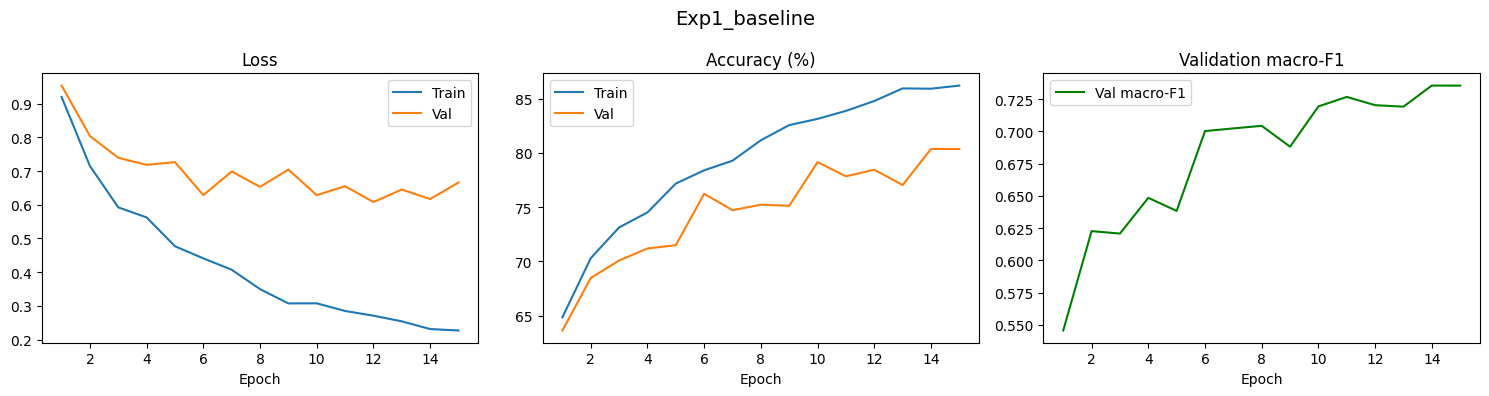


  Experiment_1_baseline — Test Metrics
  Macro F1 : 0.6380
  AUC-ROC  : 0.9643

  Recall malignant classes:
    mel: 0.7034
    bcc: 0.8108
    akiec: 0.5200

              precision    recall  f1-score   support

          nv       0.95      0.83      0.89       701
         mel       0.47      0.70      0.56       118
         bkl       0.66      0.75      0.70       100
         bcc       0.65      0.81      0.72        37
       akiec       0.52      0.52      0.52        25
        vasc       0.47      0.88      0.61         8
          df       0.75      0.33      0.46         9

    accuracy                           0.80       998
   macro avg       0.64      0.69      0.64       998
weighted avg       0.83      0.80      0.81       998



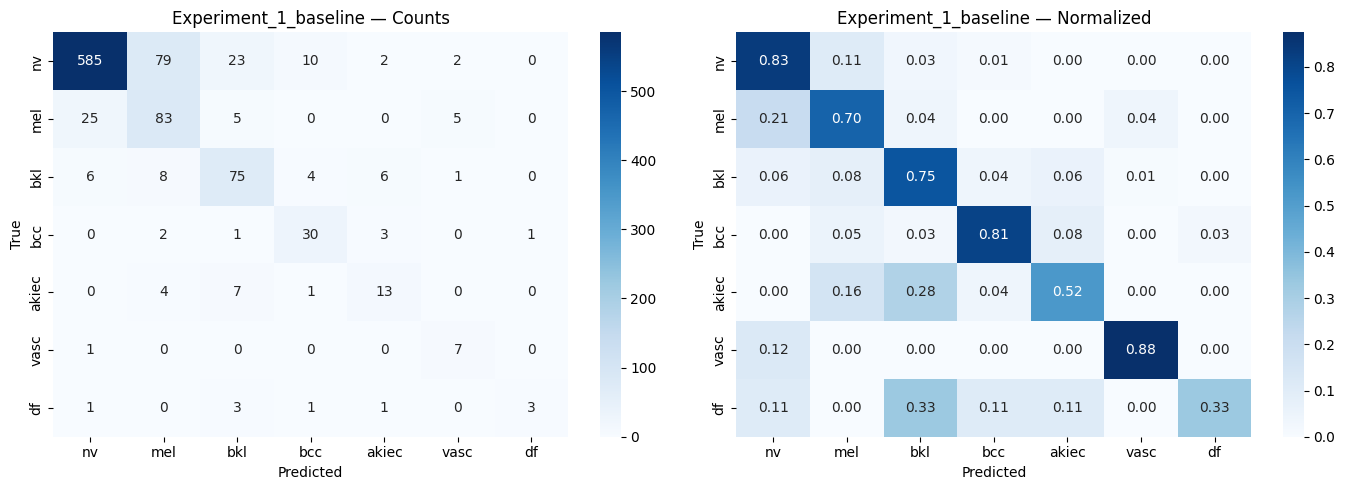

In [ ]:
# ============================
# Experiment 1 — Baseline Phase 2 (no extras)
# ============================
model_exp1 = build_efficientnet_b2(num_classes=7, freeze_backbone=False).to(device)
model_exp1.load_state_dict(torch.load("models/phase1_checkpoint.pt", map_location=device))
unfreeze_backbone(model_exp1)

optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=1e-4, weight_decay=1e-5)

print("=== Experiment 1: Baseline Phase 2 ===")
history_exp1 = train_model(
    model=model_exp1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_exp1,
    scheduler=None,
    device=device,
    num_epochs=15,
    model_name="exp1_EN_baseline.pt"
)

plot_history(history_exp1, "Exp1_EN_baseline")
model_exp1.load_state_dict(torch.load("models/exp1_EN_baseline.pt", map_location=device))
f1_exp1 = compute_metrics(model_exp1, test_loader, device, "Experiment_1_baseline")


## Experiment 2 — Same Phase 1 + WeightedRandomSampler in Phase 2


**Hypothesis:** WeightedRandomSampler will improve recall on minority classes
(mel, bcc, akiec, df, vasc) by ensuring each batch sees a more balanced
distribution of classes during fine-tuning.

Backbone unfrozen — all parameters will be updated.
=== Experiment 2: WeightedRandomSampler ===
Epoch [1/15] train_loss: 0.3992 train_acc: 66.9% | val_loss: 1.3876 val_acc: 51.7% val_F1: 0.4596
 Saved best model (val_F1=0.4596)
Epoch [2/15] train_loss: 0.2108 train_acc: 75.1% | val_loss: 1.2231 val_acc: 59.4% val_F1: 0.5752
 Saved best model (val_F1=0.5752)
Epoch [3/15] train_loss: 0.1581 train_acc: 80.0% | val_loss: 1.3114 val_acc: 56.4% val_F1: 0.5424
Epoch [4/15] train_loss: 0.1374 train_acc: 81.8% | val_loss: 1.1258 val_acc: 60.7% val_F1: 0.5947
 Saved best model (val_F1=0.5947)
Epoch [5/15] train_loss: 0.1044 train_acc: 84.0% | val_loss: 1.2382 val_acc: 60.7% val_F1: 0.5992
 Saved best model (val_F1=0.5992)
Epoch [6/15] train_loss: 0.0930 train_acc: 85.2% | val_loss: 1.1180 val_acc: 63.4% val_F1: 0.6393
 Saved best model (val_F1=0.6393)
Epoch [7/15] train_loss: 0.0831 train_acc: 86.3% | val_loss: 1.0265 val_acc: 66.5% val_F1: 0.6532
 Saved best model (val_F1=0.6532)
Epoch [8/15] t

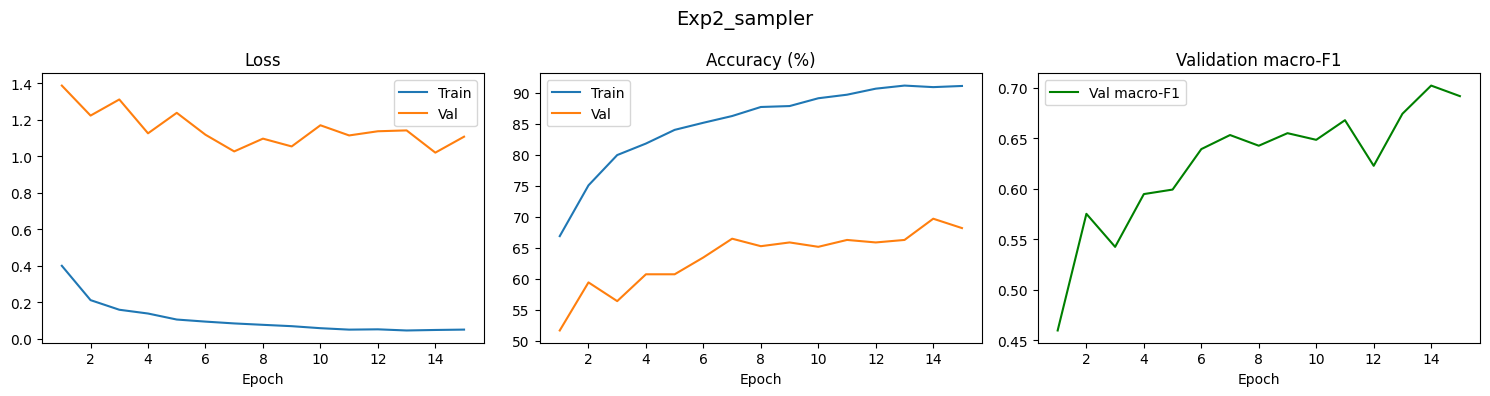


  Experiment_2_sampler — Test Metrics
  Macro F1 : 0.6281
  AUC-ROC  : 0.9521

  Recall malignant classes:
    mel: 0.8729
    bcc: 0.8649
    akiec: 0.6800

              precision    recall  f1-score   support

          nv       0.99      0.60      0.75       701
         mel       0.32      0.87      0.47       118
         bkl       0.55      0.65      0.59       100
         bcc       0.46      0.86      0.60        37
       akiec       0.53      0.68      0.60        25
        vasc       0.53      1.00      0.70         8
          df       0.57      0.89      0.70         9

    accuracy                           0.65       998
   macro avg       0.56      0.79      0.63       998
weighted avg       0.83      0.65      0.69       998



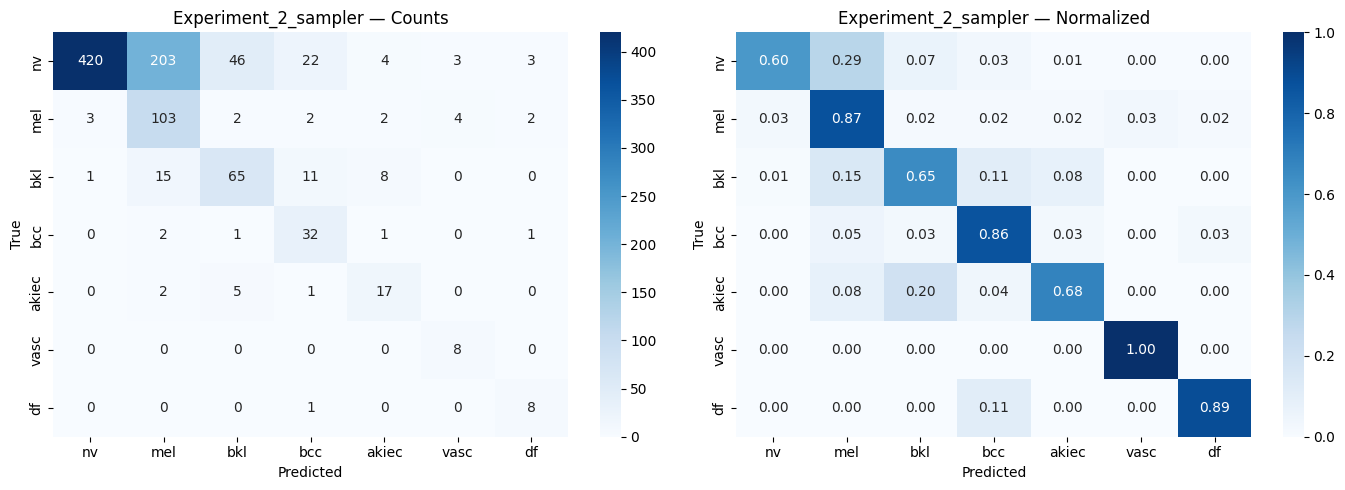

In [ ]:
# ============================
# Experiment 2 — Phase 1 checkpoint + WeightedRandomSampler in Phase 2
# ============================
model_exp2 = build_efficientnet_b2(num_classes=7, freeze_backbone=False).to(device)
model_exp2.load_state_dict(torch.load("models/phase1_checkpoint.pt", map_location=device))
unfreeze_backbone(model_exp2)

optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=1e-4, weight_decay=1e-5)

print("=== Experiment 2: WeightedRandomSampler ===")
history_exp2 = train_model(
    model=model_exp2,
    train_loader=train_loader_rs,  # sampler loader
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_exp2,
    scheduler=None,
    device=device,
    num_epochs=15,
    model_name="exp2_sampler.pt"
)

plot_history(history_exp2, "Exp2_sampler")
model_exp2.load_state_dict(torch.load("models/exp2_sampler.pt", map_location=device))
f1_exp2 = compute_metrics(model_exp2, test_loader, device, "Experiment_2_sampler")


## Experiment 3 — Same Phase 1 + ReduceLROnPlateau in Phase 2


**Hypothesis:** Adaptively reducing the learning rate when validation loss
plateaus will help the model escape local minima and converge to a better
solution during fine-tuning.

Backbone unfrozen — all parameters will be updated.
=== Experiment 3: Adaptive LR ===
Epoch [1/15] train_loss: 0.9283 train_acc: 64.7% | val_loss: 0.9252 val_acc: 62.7% val_F1: 0.5706
 Saved best model (val_F1=0.5706)
Epoch [2/15] train_loss: 0.7377 train_acc: 70.2% | val_loss: 0.8415 val_acc: 66.2% val_F1: 0.6138
 Saved best model (val_F1=0.6138)
Epoch [3/15] train_loss: 0.6022 train_acc: 72.4% | val_loss: 0.7280 val_acc: 70.8% val_F1: 0.6331
 Saved best model (val_F1=0.6331)
Epoch [4/15] train_loss: 0.5171 train_acc: 75.8% | val_loss: 0.7259 val_acc: 70.4% val_F1: 0.6394
 Saved best model (val_F1=0.6394)
Epoch [5/15] train_loss: 0.4526 train_acc: 77.1% | val_loss: 0.7044 val_acc: 73.4% val_F1: 0.6612
 Saved best model (val_F1=0.6612)
Epoch [6/15] train_loss: 0.4394 train_acc: 78.7% | val_loss: 0.6752 val_acc: 74.9% val_F1: 0.6637
 Saved best model (val_F1=0.6637)
Epoch [7/15] train_loss: 0.4023 train_acc: 79.9% | val_loss: 0.6934 val_acc: 73.8% val_F1: 0.6619
Epoch [8/15] train_loss:

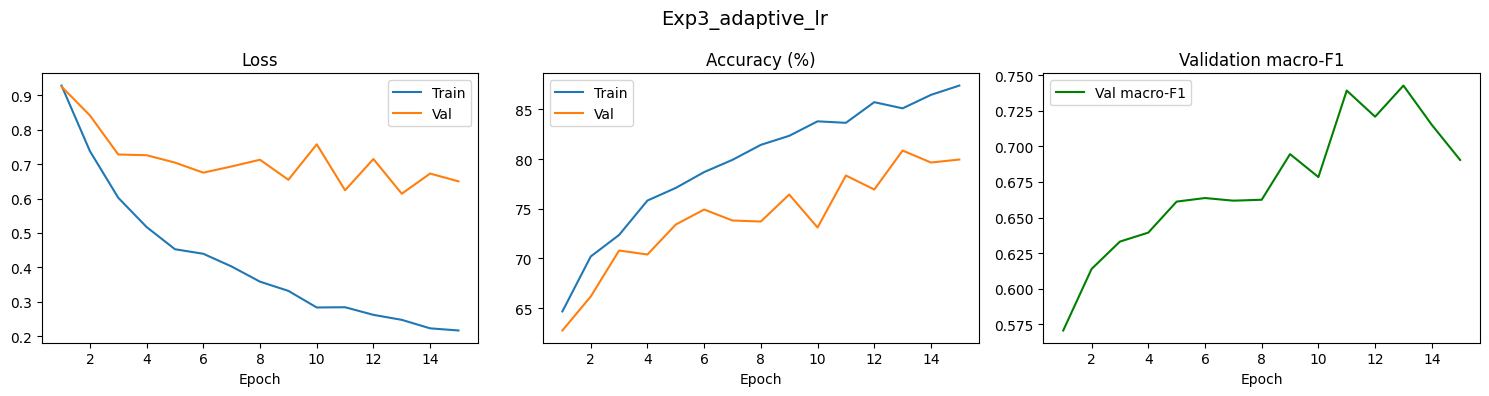


  Experiment_3_adaptive_lr — Test Metrics
  Macro F1 : 0.6800
  AUC-ROC  : 0.9619

  Recall malignant classes:
    mel: 0.7203
    bcc: 0.8108
    akiec: 0.4800

              precision    recall  f1-score   support

          nv       0.95      0.82      0.88       701
         mel       0.43      0.72      0.54       118
         bkl       0.69      0.67      0.68       100
         bcc       0.58      0.81      0.67        37
       akiec       0.50      0.48      0.49        25
        vasc       0.53      1.00      0.70         8
          df       1.00      0.67      0.80         9

    accuracy                           0.78       998
   macro avg       0.67      0.74      0.68       998
weighted avg       0.83      0.78      0.80       998



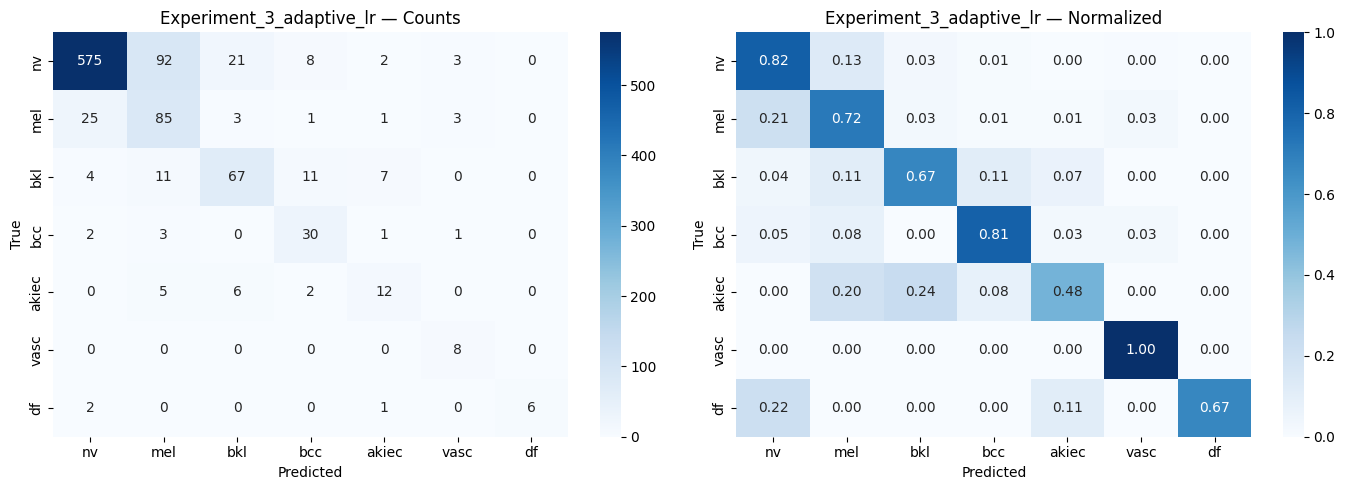

In [ ]:
# ============================
# Experiment 3 — Phase 1 checkpoint + ReduceLROnPlateau in Phase 2
# ============================
model_exp3 = build_efficientnet_b2(num_classes=7, freeze_backbone=False).to(device)
model_exp3.load_state_dict(torch.load("models/phase1_checkpoint.pt", map_location=device))
unfreeze_backbone(model_exp3)

optimizer_exp3 = optim.Adam(model_exp3.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_exp3 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp3, mode='min', patience=3, factor=0.5
)

print("=== Experiment 3: Adaptive LR ===")
history_exp3 = train_model(
    model=model_exp3,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_exp3,
    scheduler=scheduler_exp3,
    device=device,
    num_epochs=15,
    model_name="exp3_adaptive_lr.pt"
)

plot_history(history_exp3, "Exp3_adaptive_lr")
model_exp3.load_state_dict(torch.load("models/exp3_adaptive_lr.pt", map_location=device))
f1_exp3 = compute_metrics(model_exp3, test_loader, device, "Experiment_3_adaptive_lr")


In [ ]:
# ============================
# Best model selection by F1
# ============================
experiment_results = {
    "Experiment_1_baseline":    (f1_exp1, "exp1_EN_baseline.pt"),
    "Experiment_2_sampler":     (f1_exp2, "exp2_sampler.pt"),
    "Experiment_3_adaptive_lr": (f1_exp3, "exp3_adaptive_lr.pt"),
}

print("=== Best model selection by F1 ===")
for name, values in experiment_results.items():
    f1 = values[0]
    print(f"  {name}: F1 = {f1:.4f}")

best_name              = max(experiment_results, key=lambda k: experiment_results[k][0])
best_f1, best_file     = experiment_results[best_name]

print(f"\n  Best: {best_name} (F1 = {best_f1:.4f})")

# Save best as final
best_state = torch.load(f"models/{best_file}", map_location=device)
torch.save(best_state, "models/best_model_final.pt")
print("  ✅ Saved as models/best_model_final.pt — ready for Grad-CAM + FastAPI")


=== Best model selection by F1 ===
  Experiment_1_baseline: F1 = 0.6380
  Experiment_2_sampler: F1 = 0.6281
  Experiment_3_adaptive_lr: F1 = 0.6800

  Best: Experiment_3_adaptive_lr (F1 = 0.6800)
  ✅ Saved as models/best_model_final.pt — ready for Grad-CAM + FastAPI
